# 🎮 Dueling Double DQN (D3QN) — Atari RL Agent
**Bài Tập Lớn 4 — Trí tuệ Nhân tạo**

Notebook tổng hợp toàn bộ mã nguồn dự án D3QN + Prioritized Experience Replay.

**Kiến trúc kết hợp 3 cải tiến chính:**
- **Double DQN** — Chống Overestimation Bias
- **Dueling Network** — Tách biệt V(s) và A(s,a)
- **Prioritized Experience Replay** — Lấy mẫu thông minh bằng SumTree

## 1. Cài đặt thư viện

In [1]:
# Cai dat moi truong Atari
!pip install -q gymnasium[atari] ale-py autorom
!pip install -q opencv-python-headless imageio[ffmpeg]

import subprocess
subprocess.run(['AutoROM', '--accept-license'], capture_output=True)

CompletedProcess(args=['AutoROM', '--accept-license'], returncode=0, stdout=b'AutoROM will download the Atari 2600 ROMs.\nThey will be installed to:\n\t/usr/local/lib/python3.12/dist-packages/AutoROM/roms\n\nExisting ROMs will be overwritten.\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin\nInstalled /usr/local/lib/python3.12/dist-packages/AutoROM/roms/back

## 2. Import thư viện

In [2]:
import os
import random
import collections
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import ale_py
import cv2
import imageio
import matplotlib.pyplot as plt
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple, Any, SupportsFloat, Dict, List
from tqdm.notebook import tqdm
from IPython.display import Video, display

# Dang ky namespace ALE voi Gymnasium (bat buoc voi gymnasium >= 1.0)
gym.register_envs(ale_py)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'ALE envs registered: {len([e for e in gym.envs.registry if "ALE" in e])} envs')

Device: cuda
ALE envs registered: 104 envs


## 3. Tiền xử lý Môi trường Atari (Wrappers)
Các wrapper theo chuẩn DeepMind: NoopReset → MaxAndSkip → EpisodicLife → Fire → WarpFrame → ClipReward → FrameStack

In [3]:
def set_global_seeds(seed: int) -> None:
    """Set seeds for torch, numpy, random, and CUDA for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ==============================================================================
# Atari Wrappers
# ==============================================================================

class NoopResetEnv(gym.Wrapper):
    """Sample random no-ops on reset for stochastic initial states."""

    def __init__(self, env: gym.Env, noop_max: int = 30) -> None:
        super().__init__(env)
        self.noop_max = noop_max
        self.noop_action = 0
        assert env.unwrapped.get_action_meanings()[0] == "NOOP"

    def reset(self, **kwargs: Any) -> Tuple[np.ndarray, dict]:
        obs, info = self.env.reset(**kwargs)
        noops = np.random.randint(1, self.noop_max + 1)
        for _ in range(noops):
            obs, _, terminated, truncated, info = self.env.step(self.noop_action)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)
        return obs, info


class MaxAndSkipEnv(gym.Wrapper):
    """Return max-pooled obs over last 2 of every `skip` frames."""

    def __init__(self, env: gym.Env, skip: int = 4) -> None:
        super().__init__(env)
        self._skip = skip
        self._obs_buffer = np.zeros(
            (2,) + env.observation_space.shape, dtype=np.uint8
        )

    def step(self, action: int) -> Tuple[np.ndarray, SupportsFloat, bool, bool, dict]:
        total_reward = 0.0
        terminated = truncated = False
        for i in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            if i == self._skip - 2:
                self._obs_buffer[0] = obs
            if i == self._skip - 1:
                self._obs_buffer[1] = obs
            total_reward += float(reward)
            if terminated or truncated:
                break
        max_frame = self._obs_buffer.max(axis=0)
        return max_frame, total_reward, terminated, truncated, info


class EpisodicLifeEnv(gym.Wrapper):
    """Make end-of-life == end-of-episode (training only)."""

    def __init__(self, env: gym.Env) -> None:
        super().__init__(env)
        self.lives = 0
        self.was_real_done = True

    def step(self, action: int) -> Tuple[np.ndarray, SupportsFloat, bool, bool, dict]:
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.was_real_done = terminated or truncated
        lives = self.env.unwrapped.ale.lives()
        if 0 < lives < self.lives:
            terminated = True
        self.lives = lives
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs: Any) -> Tuple[np.ndarray, dict]:
        if self.was_real_done:
            obs, info = self.env.reset(**kwargs)
        else:
            obs, _, _, _, info = self.env.step(0)
        self.lives = self.env.unwrapped.ale.lives()
        return obs, info


class FireResetEnv(gym.Wrapper):
    """Press FIRE at reset for environments that require it."""

    def __init__(self, env: gym.Env) -> None:
        super().__init__(env)
        assert env.unwrapped.get_action_meanings()[1] == "FIRE"
        assert len(env.unwrapped.get_action_meanings()) >= 3

    def reset(self, **kwargs: Any) -> Tuple[np.ndarray, dict]:
        self.env.reset(**kwargs)
        obs, _, terminated, truncated, info = self.env.step(1)
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)
        obs, _, terminated, truncated, info = self.env.step(2)
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)
        return obs, info


class WarpFrame(gym.ObservationWrapper):
    """Convert to grayscale and resize to 84x84."""

    def __init__(self, env: gym.Env, width: int = 84, height: int = 84) -> None:
        super().__init__(env)
        self.width = width
        self.height = height
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(self.height, self.width, 1), dtype=np.uint8
        )

    def observation(self, frame: np.ndarray) -> np.ndarray:
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(frame, (self.width, self.height),
                           interpolation=cv2.INTER_AREA)
        return frame[:, :, np.newaxis]


class ClipRewardEnv(gym.RewardWrapper):
    """Clip rewards to {-1, 0, +1} using np.sign."""

    def reward(self, reward: SupportsFloat) -> float:
        return float(np.sign(float(reward)))


class FrameStackEnv(gym.Wrapper):
    """Stack the last `n_frames` as observation channels."""

    def __init__(self, env: gym.Env, n_frames: int = 4) -> None:
        super().__init__(env)
        self.n_frames = n_frames
        self.frames: deque = deque([], maxlen=n_frames)
        shp = env.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255,
            shape=(shp[0], shp[1], shp[2] * n_frames),
            dtype=np.uint8,
        )

    def reset(self, **kwargs: Any) -> Tuple[np.ndarray, dict]:
        obs, info = self.env.reset(**kwargs)
        for _ in range(self.n_frames):
            self.frames.append(obs)
        return self._get_obs(), info

    def step(self, action: int) -> Tuple[np.ndarray, SupportsFloat, bool, bool, dict]:
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(obs)
        return self._get_obs(), reward, terminated, truncated, info

    def _get_obs(self) -> np.ndarray:
        assert len(self.frames) == self.n_frames
        return np.concatenate(list(self.frames), axis=2)


# ==============================================================================
# Environment Factory
# ==============================================================================

def make_atari_env(
    env_name: str,
    seed: int = 42,
    frame_stack: int = 4,
    clip_rewards: bool = True,
    episodic_life: bool = True,
    render_mode: Optional[str] = None,
) -> gym.Env:
    """
    Create a fully-wrapped Atari environment following DeepMind's protocol.

    Args:
        env_name:      Gymnasium Atari environment ID.
        seed:          Random seed for the environment.
        frame_stack:   Number of frames to stack.
        clip_rewards:  Whether to clip rewards to {-1, 0, +1}.
        episodic_life: Whether to treat life loss as episode end.
        render_mode:   Gymnasium render mode (None, 'human', 'rgb_array').

    Returns:
        Fully wrapped Gymnasium environment.
    """
    env = gym.make(env_name, render_mode=render_mode)
    env = NoopResetEnv(env, noop_max=30)
    env = MaxAndSkipEnv(env, skip=4)
    if episodic_life:
        env = EpisodicLifeEnv(env)
    if "FIRE" in env.unwrapped.get_action_meanings():
        env = FireResetEnv(env)
    env = WarpFrame(env)
    if clip_rewards:
        env = ClipRewardEnv(env)
    env = FrameStackEnv(env, n_frames=frame_stack)
    env.reset(seed=seed)
    return env


def preprocess_observation(obs: np.ndarray) -> np.ndarray:
    """Convert HWC uint8 obs to CHW float32 in [0, 1]."""
    obs = np.array(obs, dtype=np.float32) / 255.0
    return np.transpose(obs, (2, 0, 1))  # HWC -> CHW

## 4. Prioritized Experience Replay (SumTree & Buffer)
Cấu trúc SumTree cho phép lấy mẫu theo xác suất ưu tiên với thời gian O(log N).

In [4]:
@dataclass
class Transition:
    """A single experience transition (s, a, r, s', done)."""
    state: np.ndarray
    action: int
    reward: float
    next_state: np.ndarray
    done: bool


class SumTree:
    """Binary Sum-Tree for O(log N) proportional-priority sampling."""

    def __init__(self, capacity: int) -> None:
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1, dtype=np.float64)
        self.data: list[Optional[Transition]] = [None] * capacity
        self.write_idx = 0
        self.size = 0

    def _propagate(self, idx: int, delta: float) -> None:
        parent = (idx - 1) // 2
        self.tree[parent] += delta
        if parent != 0:
            self._propagate(parent, delta)

    def _retrieve(self, idx: int, value: float) -> int:
        left = 2 * idx + 1
        right = 2 * idx + 2
        if left >= len(self.tree):
            return idx
        if value <= self.tree[left]:
            return self._retrieve(left, value)
        else:
            return self._retrieve(right, value - self.tree[left])

    @property
    def total_priority(self) -> float:
        return float(self.tree[0])

    @property
    def max_priority(self) -> float:
        if self.size == 0:
            return 1.0
        leaf_start = self.capacity - 1
        return float(np.max(self.tree[leaf_start:leaf_start + self.size]))

    def add(self, priority: float, transition: Transition) -> None:
        tree_idx = self.write_idx + self.capacity - 1
        self.data[self.write_idx] = transition
        self.update(tree_idx, priority)
        self.write_idx = (self.write_idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update(self, tree_idx: int, priority: float) -> None:
        delta = priority - self.tree[tree_idx]
        self.tree[tree_idx] = priority
        self._propagate(tree_idx, delta)

    def get(self, value: float) -> Tuple[int, float, Transition]:
        tree_idx = self._retrieve(0, value)
        data_idx = tree_idx - self.capacity + 1
        return tree_idx, self.tree[tree_idx], self.data[data_idx]


class PrioritizedReplayBuffer:
    """
    PER buffer with importance-sampling correction.

    Args:
        capacity: Max transitions. alpha: priority exponent.
        beta_start/end: IS exponent annealing range.
        beta_anneal_steps: Steps to anneal beta. epsilon: prevents zero priority.
    """

    def __init__(self, capacity: int = 100000, alpha: float = 0.6,
                 beta_start: float = 0.4, beta_end: float = 1.0,
                 beta_anneal_steps: int = 100000, epsilon: float = 1e-6) -> None:
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.beta_anneal_steps = beta_anneal_steps
        self.epsilon = epsilon
        self._step = 0

    @property
    def beta(self) -> float:
        fraction = min(1.0, self._step / max(1, self.beta_anneal_steps))
        return self.beta_start + fraction * (self.beta_end - self.beta_start)

    def __len__(self) -> int:
        return self.tree.size

    def add(self, state: np.ndarray, action: int, reward: float,
            next_state: np.ndarray, done: bool) -> None:
        # Luu state dang uint8 de tiet kiem RAM (giam 4x so voi float32)
        # state hien tai la float32 [0,1] tu preprocess_observation
        state_u8 = (state * 255).clip(0, 255).astype(np.uint8)
        next_state_u8 = (next_state * 255).clip(0, 255).astype(np.uint8)
        transition = Transition(state=state_u8, action=action, reward=reward,
                                next_state=next_state_u8, done=done)
        max_p = self.tree.max_priority
        priority = max_p ** self.alpha if max_p > 0 else 1.0
        self.tree.add(priority, transition)

    def sample(self, batch_size: int) -> Tuple[np.ndarray, np.ndarray,
            np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Sample a prioritized batch with IS weights (stratified)."""
        self._step += 1
        states, actions, rewards, next_states, dones = [], [], [], [], []
        indices, priorities = [], []
        segment = self.tree.total_priority / batch_size

        for i in range(batch_size):
            value = np.random.uniform(segment * i, segment * (i + 1))
            tree_idx, priority, transition = self.tree.get(value)
            if transition is None:
                value = np.random.uniform(0, self.tree.total_priority)
                tree_idx, priority, transition = self.tree.get(value)
            indices.append(tree_idx)
            priorities.append(priority)
            states.append(transition.state)
            actions.append(transition.action)
            rewards.append(transition.reward)
            next_states.append(transition.next_state)
            dones.append(transition.done)

        priorities_arr = np.array(priorities, dtype=np.float64)
        sampling_probs = np.maximum(priorities_arr / self.tree.total_priority, 1e-10)
        is_weights = (len(self) * sampling_probs) ** (-self.beta)
        is_weights /= is_weights.max()

        return (np.array(states, dtype=np.uint8).astype(np.float32) / 255.0,
                np.array(actions, dtype=np.int64),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.uint8).astype(np.float32) / 255.0,
                np.array(dones, dtype=np.float32),
                np.array(indices, dtype=np.int64),
                np.array(is_weights, dtype=np.float32))

    def update_priorities(self, tree_indices: np.ndarray,
                          td_errors: np.ndarray) -> None:
        """Update priorities: p_i = (|delta_i| + eps)^alpha."""
        for idx, td_error in zip(tree_indices, td_errors):
            priority = (abs(td_error) + self.epsilon) ** self.alpha
            self.tree.update(int(idx), float(priority))

## 5. Kiến trúc Mạng Nơ-ron (Dueling DQN)
Tách hai luồng Value V(s) và Advantage A(s,a), kết hợp bằng công thức:
$$Q(s,a) = V(s) + A(s,a) - \\text{mean}(A)$$

In [5]:
class DuelingDQN(nn.Module):
    """
    Dueling Deep Q-Network with convolutional feature extraction.

    Architecture follows the DeepMind Nature paper's CNN backbone,
    then splits into two streams:
        - Value stream V(s): scalar state-value estimate
        - Advantage stream A(s,a): per-action advantage estimates

    The streams are combined using the mean-subtraction formula to
    ensure identifiability:
        Q(s, a) = V(s) + (A(s, a) - mean_a'(A(s, a')))

    Args:
        input_shape: Shape of input observations (C, H, W).
                     Typically (4, 84, 84) for stacked Atari frames.
        n_actions:   Number of discrete actions in the environment.
    """

    def __init__(self, input_shape: Tuple[int, ...], n_actions: int) -> None:
        super().__init__()

        self.input_shape = input_shape
        self.n_actions = n_actions

        # === Convolutional Feature Extractor (shared backbone) ===
        # Follows the architecture from Mnih et al. (2015) Nature paper
        self.features = nn.Sequential(
            # Conv1: 32 filters, 8x8 kernel, stride 4
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(inplace=True),
            # Conv2: 64 filters, 4x4 kernel, stride 2
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(inplace=True),
            # Conv3: 64 filters, 3x3 kernel, stride 1
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
        )

        # Compute the flattened feature size dynamically
        self._feature_size = self._get_conv_output_size(input_shape)

        # === Value Stream V(s) ===
        # Outputs a single scalar: the state value
        self.value_stream = nn.Sequential(
            nn.Linear(self._feature_size, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1),
        )

        # === Advantage Stream A(s, a) ===
        # Outputs one value per action: the advantage of each action
        self.advantage_stream = nn.Sequential(
            nn.Linear(self._feature_size, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, n_actions),
        )

        # Initialize weights using Kaiming (He) initialization
        self._initialize_weights()

    def _get_conv_output_size(self, shape: Tuple[int, ...]) -> int:
        """
        Compute the output size of the convolutional layers by
        performing a forward pass with a dummy tensor.

        Args:
            shape: Input tensor shape (C, H, W).

        Returns:
            Flattened feature vector size (int).
        """
        with torch.no_grad():
            dummy = torch.zeros(1, *shape)
            output = self.features(dummy)
            return int(np.prod(output.shape[1:]))

    def _initialize_weights(self) -> None:
        """
        Apply Kaiming (He) uniform initialization to all layers.

        This initialization scheme is designed for ReLU activations
        and helps prevent vanishing/exploding gradients in deep networks.
        """
        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the Dueling DQN.

        Computes Q-values by combining the value and advantage streams:
            Q(s, a) = V(s) + (A(s, a) - mean_a'(A(s, a')))

        The mean subtraction ensures identifiability: given Q, we can
        uniquely recover V and A (up to a constant shift).

        Args:
            x: Batch of observations, shape (B, C, H, W).
               Values should be in [0, 1] (normalized pixel values).

        Returns:
            Q-values for all actions, shape (B, n_actions).
        """
        # Shared convolutional features
        features = self.features(x)
        features = features.reshape(features.size(0), -1)  # Flatten

        # Separate streams
        value: torch.Tensor = self.value_stream(features)          # (B, 1)
        advantage: torch.Tensor = self.advantage_stream(features)  # (B, n_actions)

        # Combine: Q = V + (A - mean(A))
        # Mean subtraction for identifiability (Wang et al., 2016, Eq. 9)
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))

        return q_values

    def get_action(self, state: torch.Tensor) -> int:
        """
        Select the greedy action (argmax Q) for a single state.

        Args:
            state: Single observation tensor, shape (1, C, H, W).

        Returns:
            Action index with highest Q-value.
        """
        with torch.no_grad():
            q_values = self.forward(state)
            return int(q_values.argmax(dim=1).item())

## 6. Tác tử D3QN (Agent Logic)
Kết hợp Double DQN + Dueling + PER trong một Agent duy nhất.

In [6]:
class D3QNAgent:
    """
    Dueling Double DQN Agent with Prioritized Experience Replay.

    Key mechanisms:
        - epsilon-greedy exploration with linear decay
        - Double DQN target computation (online selects, target evaluates)
        - Huber loss (SmoothL1) weighted by IS weights from PER
        - Hard or soft (Polyak) target network updates

    Args:
        state_shape:  Observation shape (C, H, W).
        n_actions:    Number of discrete actions.
        config:       Dictionary of hyperparameters from YAML config.
        device:       Torch device ('cpu' or 'cuda').
    """

    def __init__(self, state_shape: tuple, n_actions: int,
                 config: Dict[str, Any], device: torch.device) -> None:
        self.n_actions = n_actions
        self.device = device
        self.gamma = config["agent"]["gamma"]
        self.tau = config["agent"]["tau"]
        self.target_update_freq = config["agent"]["target_update_freq"]
        self.grad_clip = config["agent"]["grad_clip"]
        self.batch_size = config["agent"]["batch_size"]

        # Exploration schedule
        self.epsilon = config["epsilon"]["start"]
        self.epsilon_end = config["epsilon"]["end"]
        self.epsilon_decay_steps = config["epsilon"]["decay_steps"]
        self._eps_step = 0

        # Networks
        self.online_net = DuelingDQN(state_shape, n_actions).to(device)
        self.target_net = DuelingDQN(state_shape, n_actions).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()  # Target net is never trained directly

        # Optimizer & loss
        self.optimizer = optim.Adam(
            self.online_net.parameters(),
            lr=config["agent"]["learning_rate"],
        )
        self.loss_fn = nn.SmoothL1Loss(reduction="none")  # Huber loss

        # Replay buffer (PER)
        buf_cfg = config["buffer"]
        self.replay_buffer = PrioritizedReplayBuffer(
            capacity=buf_cfg["capacity"],
            alpha=buf_cfg["alpha"],
            beta_start=buf_cfg["beta_start"],
            beta_end=buf_cfg["beta_end"],
            beta_anneal_steps=buf_cfg["beta_anneal_steps"],
            epsilon=buf_cfg["epsilon"],
        )

        # Counters
        self.learn_step_counter = 0

    @property
    def current_epsilon(self) -> float:
        """Current epsilon value (linearly decayed)."""
        return self.epsilon

    def select_action(self, state: np.ndarray) -> int:
        """
        Select action using epsilon-greedy policy.

        With probability epsilon: random action (exploration).
        Otherwise: greedy action from online network (exploitation).
        """
        # Decay epsilon
        self._eps_step += 1
        self.epsilon = max(
            self.epsilon_end,
            1.0 - (1.0 - self.epsilon_end) * self._eps_step / self.epsilon_decay_steps,
        )

        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)

        state_t = torch.tensor(state, dtype=torch.float32,
                               device=self.device).unsqueeze(0)
        return self.online_net.get_action(state_t)

    def store_transition(self, state: np.ndarray, action: int,
                         reward: float, next_state: np.ndarray,
                         done: bool) -> None:
        """Store a transition in the replay buffer."""
        self.replay_buffer.add(state, action, reward, next_state, done)

    def learn(self) -> Dict[str, float]:
        """
        Perform one gradient step using Double DQN with PER.

        Returns dict with: loss, mean_q, grad_norm.

        Double DQN target:
            y = r + gamma * Q_target(s', argmax_a' Q_online(s', a'))
        """
        if len(self.replay_buffer) < self.batch_size:
            return {"loss": 0.0, "mean_q": 0.0, "grad_norm": 0.0}

        # Sample from PER
        (states, actions, rewards, next_states, dones,
         tree_indices, is_weights) = self.replay_buffer.sample(self.batch_size)

        # Convert to tensors
        states_t = torch.tensor(states, device=self.device)
        actions_t = torch.tensor(actions, device=self.device).unsqueeze(1)
        rewards_t = torch.tensor(rewards, device=self.device).unsqueeze(1)
        next_states_t = torch.tensor(next_states, device=self.device)
        dones_t = torch.tensor(dones, device=self.device).unsqueeze(1)
        weights_t = torch.tensor(is_weights, device=self.device).unsqueeze(1)

        # --- Double DQN Target Computation ---
        # Step 1: Online network selects best action for next state
        with torch.no_grad():
            next_q_online = self.online_net(next_states_t)
            best_actions = next_q_online.argmax(dim=1, keepdim=True)

            # Step 2: Target network evaluates that action
            next_q_target = self.target_net(next_states_t)
            next_q_value = next_q_target.gather(1, best_actions)

            # TD target: y = r + gamma * Q_target(s', a*) * (1 - done)
            td_target = rewards_t + self.gamma * next_q_value * (1.0 - dones_t)

        # Current Q-values for taken actions
        current_q = self.online_net(states_t).gather(1, actions_t)

        # Weighted Huber loss (IS weights from PER)
        element_wise_loss = self.loss_fn(current_q, td_target)
        loss = (element_wise_loss * weights_t).mean()

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for stability
        grad_norm = nn.utils.clip_grad_norm_(
            self.online_net.parameters(), self.grad_clip
        )
        self.optimizer.step()

        # Update PER priorities with new TD-errors
        td_errors = (current_q - td_target).detach().cpu().numpy().flatten()
        self.replay_buffer.update_priorities(tree_indices, np.abs(td_errors))

        # Update target network
        self.learn_step_counter += 1
        if self.tau < 1.0:
            self._soft_update()
        elif self.learn_step_counter % self.target_update_freq == 0:
            self._hard_update()

        return {
            "loss": loss.item(),
            "mean_q": current_q.mean().item(),
            "grad_norm": float(grad_norm),
        }

    def _hard_update(self) -> None:
        """Copy online network weights to target network."""
        self.target_net.load_state_dict(self.online_net.state_dict())

    def _soft_update(self) -> None:
        """Polyak averaging: theta_target = tau*theta_online + (1-tau)*theta_target."""
        for target_param, online_param in zip(
            self.target_net.parameters(), self.online_net.parameters()
        ):
            target_param.data.copy_(
                self.tau * online_param.data + (1.0 - self.tau) * target_param.data
            )

    def save_checkpoint(self, filepath: str) -> None:
        """Save agent state to a checkpoint file."""
        checkpoint = {
            "online_net": self.online_net.state_dict(),
            "target_net": self.target_net.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "epsilon": self.epsilon,
            "learn_step_counter": self.learn_step_counter,
            "eps_step": self._eps_step,
        }
        torch.save(checkpoint, filepath)

    def load_checkpoint(self, filepath: str) -> None:
        """Load agent state from a checkpoint file."""
        checkpoint = torch.load(filepath, map_location=self.device,
                                weights_only=True)
        self.online_net.load_state_dict(checkpoint["online_net"])
        self.target_net.load_state_dict(checkpoint["target_net"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.epsilon = checkpoint["epsilon"]
        self.learn_step_counter = checkpoint["learn_step_counter"]
        self._eps_step = checkpoint["eps_step"]

## 7. Logger (phiên bản đơn giản cho Colab)

In [7]:
class RLLogger:
    def __init__(self, log_dir='logs'):
        os.makedirs(log_dir, exist_ok=True)
        self.log_path = os.path.join(log_dir, 'training.log')
        self.f = open(self.log_path, 'w')
    def log_episode(self, ep, reward, length, epsilon):
        line = f'ep={ep}, reward={reward:.1f}, length={length}, eps={epsilon:.4f}'
        self.f.write(line + '\n')
        self.f.flush()
    def log_training_step(self, step, loss, mean_q, grad_norm):
        pass
    def log_buffer_stats(self, step, size, beta):
        pass
    def close(self):
        self.f.close()

## 8. Cấu hình Huấn luyện
Config này đã được tối uư cho Colab FREE tier (12GB RAM).
Buffer uint8 + 30K capacity = ~1.6GB RAM. Để train toàn bộ 300K steps mất khoảng 1-2 giờ.

In [8]:
config = {
    'env': {
        'name': 'ALE/Pong-v5',
        'frame_stack': 4,
        'clip_rewards': True,
        'episodic_life': True
    },
    'agent': {
        'gamma': 0.99,
        'lr': 1e-4,
        'learning_rate': 1e-4,
        'batch_size': 32,
        'target_update_freq': 10000,
        'tau': 1.0,
        'grad_clip': 10.0
    },
    # Buffer 30K uint8: chi ~1.6GB RAM (phu hop Colab FREE)
    'buffer': {
        'capacity': 30000,
        'alpha': 0.6,
        'beta_start': 0.4,
        'beta_end': 1.0,
        'beta_frames': 100000,
        'beta_anneal_steps': 100000,
        'epsilon': 1e-6
    },
    'epsilon': {
        'start': 1.0,
        'end': 0.01,
        'decay_steps': 100000
    },
    'training': {
        'total_timesteps': 300000,  # ~1-2 gio tren Colab T4
        'learning_starts': 10000,
        'train_freq': 4,
        'save_interval': 50000,
        'log_interval': 10
    },
    'paths': {
        'checkpoint_dir': 'checkpoints',
        'log_dir': 'logs'
    },
    'seed': 42
}

print('Config da san sang!')
print(f"   Env: {config['env']['name']}")
print(f"   Buffer: {config['buffer']['capacity']:,} transitions (uint8, ~1.6GB RAM)")
print(f"   Total timesteps: {config['training']['total_timesteps']:,}")

Config da san sang!
   Env: ALE/Pong-v5
   Buffer: 30,000 transitions (uint8, ~1.6GB RAM)
   Total timesteps: 300,000


## 9. Vòng lặp Huấn luyện (Training Loop)
Đây là hàm `train()` chính. Chạy cell bên dưới để bắt đầu huấn luyện.

In [14]:
def train(config: Dict[str, Any], device: torch.device) -> None:
    """
    Main training loop for D3QN.

    Flow:
        1. Create environment with DeepMind wrappers
        2. Initialize D3QN agent
        3. Collect transitions with epsilon-greedy
        4. Train after warmup period
        5. Periodically log, evaluate, and checkpoint
    """
    seed = config["seed"]
    set_global_seeds(seed)

    # --- Paths ---
    ckpt_dir = Path(config["paths"]["checkpoint_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # --- Environment ---
    env_name = config["env"]["name"]
    env = make_atari_env(
        env_name, seed=seed,
        frame_stack=config["env"]["frame_stack"],
        clip_rewards=config["env"]["clip_rewards"],
        episodic_life=config["env"]["episodic_life"],
    )

    # Derive state shape (CHW) and action count
    obs_shape = env.observation_space.shape  # (H, W, C*stack)
    state_shape = (obs_shape[2], obs_shape[0], obs_shape[1])  # (C, H, W)
    n_actions = env.action_space.n

    print("=" * 60)
    print(f"  D3QN Training — {env_name}")
    print(f"  State shape: {state_shape} | Actions: {n_actions}")
    print(f"  Device: {device} | Seed: {seed}")
    print("=" * 60)

    # --- Agent ---
    agent = D3QNAgent(state_shape, n_actions, config, device)

    # --- Logger ---
    logger = RLLogger(log_dir=config["paths"]["log_dir"])

    # --- Training ---
    training_cfg = config["training"]
    total_timesteps = training_cfg["total_timesteps"]
    learning_starts = training_cfg["learning_starts"]
    train_freq = training_cfg["train_freq"]
    save_interval = training_cfg["save_interval"]
    log_interval = training_cfg["log_interval"]

    obs, _ = env.reset()
    state = preprocess_observation(obs)

    episode_reward = 0.0
    episode_length = 0
    episode_count = 0
    recent_rewards: list[float] = []

    pbar = tqdm(range(1, total_timesteps + 1), desc="Training", unit="step")

    for step in pbar:
        # --- Action Selection ---
        action = agent.select_action(state)

        # --- Environment Step ---
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        next_state = preprocess_observation(next_obs)

        # --- Store Transition ---
        agent.store_transition(state, action, float(reward), next_state, done)

        state = next_state
        episode_reward += float(reward)
        episode_length += 1

        # --- Learn ---
        metrics = {"loss": 0.0, "mean_q": 0.0, "grad_norm": 0.0}
        if step >= learning_starts and step % train_freq == 0:
            metrics = agent.learn()
            logger.log_training_step(
                step, metrics["loss"], metrics["mean_q"], metrics["grad_norm"]
            )
            logger.log_buffer_stats(
                step, len(agent.replay_buffer), agent.replay_buffer.beta
            )

        # --- Episode End ---
        if done:
            episode_count += 1
            recent_rewards.append(episode_reward)

            logger.log_episode(
                episode_count, episode_reward, episode_length, agent.current_epsilon
            )

            # Update progress bar
            avg_reward = np.mean(recent_rewards[-100:])
            pbar.set_postfix({
                "ep": episode_count,
                "reward": f"{episode_reward:.1f}",
                "avg100": f"{avg_reward:.1f}",
                "eps": f"{agent.current_epsilon:.3f}",
                "loss": f"{metrics['loss']:.4f}",
            })

            # Print periodic summary
            if episode_count % log_interval == 0:
                print(
                    f"\n[Episode {episode_count}] "
                    f"Avg Reward (100): {avg_reward:.2f} | "
                    f"Epsilon: {agent.current_epsilon:.4f} | "
                    f"Buffer: {len(agent.replay_buffer)} | "
                    f"Steps: {step}"
                )

            # Reset
            obs, _ = env.reset()
            state = preprocess_observation(obs)
            episode_reward = 0.0
            episode_length = 0

        # --- Checkpoint ---
        if step % save_interval == 0:
            env_name_safe = env_name.replace("/", "_").replace("\\", "_")
            ckpt_path = str(ckpt_dir / f"d3qn_{env_name_safe}_{step}.pt")
            agent.save_checkpoint(ckpt_path)
            print(f"\n  [Checkpoint] Saved to {ckpt_path}")

    # --- Final Save ---
    env_name_safe = env_name.replace("/", "_").replace("\\", "_")
    final_path = str(ckpt_dir / f"d3qn_{env_name_safe}_final.pt")
    agent.save_checkpoint(final_path)
    print(f"\n[Training Complete] Final checkpoint: {final_path}")
    print(f"  Total episodes: {episode_count}")
    print(f"  Final avg reward (100): {np.mean(recent_rewards[-100:]):.2f}")

    logger.close()
    env.close()
    return agent

In [15]:
# Load checkpoint thay vi train lai
from pathlib import Path
env_tmp = make_atari_env(config['env']['name'], seed=42, clip_rewards=False, episodic_life=False)
obs_shape = env_tmp.observation_space.shape
state_shape = (obs_shape[2], obs_shape[0], obs_shape[1])
n_actions = env_tmp.action_space.n
env_tmp.close()
agent = D3QNAgent(state_shape, n_actions, config, device)
agent.load_checkpoint('checkpoints/d3qn_ALE_Pong-v5_final.pt')
agent.online_net.eval()
print("Agent loaded!")

Agent loaded!


## 10. Bắt đầu Huấn luyện!
Chạy cell bên dưới để train D3QN trên GPU. Quá trình sẽ mất khoảng **1-3 giờ** tùy `total_timesteps`.

In [10]:
agent = train(config, device)

  D3QN Training — ALE/Pong-v5
  State shape: (4, 84, 84) | Actions: 6
  Device: cuda | Seed: 42


Training:   0%|          | 0/300000 [00:00<?, ?step/s]


[Episode 10] Avg Reward (100): -20.70 | Epsilon: 0.9799 | Buffer: 2027 | Steps: 2027

[Episode 20] Avg Reward (100): -20.65 | Epsilon: 0.9591 | Buffer: 4134 | Steps: 4134

[Episode 30] Avg Reward (100): -20.70 | Epsilon: 0.9383 | Buffer: 6230 | Steps: 6230

[Episode 40] Avg Reward (100): -20.65 | Epsilon: 0.9172 | Buffer: 8363 | Steps: 8363

[Episode 50] Avg Reward (100): -20.64 | Epsilon: 0.8962 | Buffer: 10481 | Steps: 10481

[Episode 60] Avg Reward (100): -20.68 | Epsilon: 0.8765 | Buffer: 12472 | Steps: 12472

[Episode 70] Avg Reward (100): -20.69 | Epsilon: 0.8555 | Buffer: 14593 | Steps: 14593

[Episode 80] Avg Reward (100): -20.70 | Epsilon: 0.8344 | Buffer: 16728 | Steps: 16728

[Episode 90] Avg Reward (100): -20.69 | Epsilon: 0.8133 | Buffer: 18854 | Steps: 18854

[Episode 100] Avg Reward (100): -20.69 | Epsilon: 0.7922 | Buffer: 20992 | Steps: 20992

[Episode 110] Avg Reward (100): -20.70 | Epsilon: 0.7722 | Buffer: 23010 | Steps: 23010

[Episode 120] Avg Reward (100): -20.7

## 11. Đánh giá & Ghi hình Gameplay
Sau khi train xong, chạy cell bên dưới để xem Agent chơi game và ghi lại video.

In [11]:
def evaluate(
    agent: D3QNAgent,
    env_name: str,
    n_episodes: int,
    seed: int,
    render: bool = False,
    record_path: str = None,
) -> Dict[str, Any]:
    """
    Run evaluation episodes and optionally record gameplay.

    Args:
        agent:       Trained D3QN agent.
        env_name:    Environment ID.
        n_episodes:  Number of episodes to evaluate.
        seed:        Random seed.
        render:      Whether to render in a window.
        record_path: If set, save recording to this path (.gif/.mp4).

    Returns:
        Dict with mean_reward, std_reward, all_rewards, all_lengths.
    """
    render_mode = "human" if render else "rgb_array" if record_path else None

    env = make_atari_env(
        env_name, seed=seed, clip_rewards=False,
        episodic_life=False, render_mode=render_mode,
    )

    all_rewards: List[float] = []
    all_lengths: List[int] = []
    frames: List[np.ndarray] = []  # For recording

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset()
        state = preprocess_observation(obs)
        episode_reward = 0.0
        episode_length = 0
        done = False

        while not done:
            # Greedy action (no exploration)
            state_t = torch.tensor(
                state, dtype=torch.float32, device=agent.device
            ).unsqueeze(0)
            action = agent.online_net.get_action(state_t)

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Capture frame for recording
            if record_path and render_mode == "rgb_array":
                frame = env.render()
                if frame is not None:
                    frames.append(frame)

            state = preprocess_observation(next_obs)
            episode_reward += float(reward)
            episode_length += 1

        all_rewards.append(episode_reward)
        all_lengths.append(episode_length)
        print(f"  Episode {ep}/{n_episodes}: "
              f"Reward = {episode_reward:.1f}, Length = {episode_length}")

    env.close()

    # Save recording
    if record_path and frames:
        save_recording(frames, record_path)

    results = {
        "mean_reward": float(np.mean(all_rewards)),
        "std_reward": float(np.std(all_rewards)),
        "min_reward": float(np.min(all_rewards)),
        "max_reward": float(np.max(all_rewards)),
        "all_rewards": all_rewards,
        "all_lengths": all_lengths,
    }

    return results


def save_recording(frames: List[np.ndarray], output_path: str) -> None:
    """
    Save recorded frames as GIF or MP4.

    Args:
        frames:      List of RGB frames (numpy arrays).
        output_path: Output file path (.gif or .mp4).
    """
    output_path = str(output_path)
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)

    if output_path.endswith(".gif"):
        imageio.mimsave(output_path, frames, fps=30, loop=0)
        print(f"  [Recording] GIF saved to {output_path} ({len(frames)} frames)")
    elif output_path.endswith(".mp4"):
        writer = imageio.get_writer(output_path, fps=30)
        for frame in frames:
            writer.append_data(frame)
        writer.close()
        print(f"  [Recording] MP4 saved to {output_path} ({len(frames)} frames)")
    else:
        print(f"  [Warning] Unsupported format. Use .gif or .mp4")

In [16]:
# Chay evaluation va ghi hinh
rewards = evaluate(agent, config['env']['name'], n_episodes=5, seed=42, record_path='gameplay.mp4')

# Hien thi video ngay trong Colab
display(Video('gameplay.mp4', embed=True))

  Episode 1/5: Reward = -19.0, Length = 392
  Episode 2/5: Reward = -18.0, Length = 456
  Episode 3/5: Reward = -18.0, Length = 401
  Episode 4/5: Reward = -18.0, Length = 640
  Episode 5/5: Reward = -19.0, Length = 371


  [Recording] MP4 saved to gameplay.mp4 (2260 frames)


---
## Baseline Comparison: Vanilla DQN vs Double DQN
Chạy 2 cell bên dưới để huấn luyện các baseline với **cùng bộ siêu tham số** như D3QN.
Kết quả sẽ được so sánh trong cell cuối.

### Vanilla DQN Baseline
Không có Dueling, không có PER — chỉ dùng Replay Buffer ngẫu nhiên.

In [17]:
import os
import collections
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
from tqdm import tqdm

# Add parent directory to path to import src modules

# ==========================================================
# 1. Standard Replay Buffer (No PER)
# ==========================================================
class StandardReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = collections.deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        states, actions, rewards, next_states, dones = zip(*[self.buffer[i] for i in indices])
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))

    def __len__(self):
        return len(self.buffer)

# ==========================================================
# 2. Vanilla DQN Network (No Dueling)
# ==========================================================
class VanillaDQNNetwork(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
        )
        # Compute dynamic size
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            out = self.features(dummy)
            feature_size = int(np.prod(out.shape[1:]))

        self.fc = nn.Sequential(
            nn.Linear(feature_size, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

    def get_action(self, state):
        with torch.no_grad():
            q_values = self.forward(state)
            return int(q_values.argmax(dim=1).item())

# ==========================================================
# 3. Vanilla DQN Agent
# ==========================================================
class VanillaDQNAgent:
    def __init__(self, state_shape, n_actions, config, device):
        self.n_actions = n_actions
        self.device = device
        self.gamma = config["agent"]["gamma"]
        self.batch_size = config["agent"]["batch_size"]
        self.target_update_freq = config["agent"]["target_update_freq"]

        # Epsilon
        self.epsilon_start = config["epsilon"]["start"]
        self.epsilon_end = config["epsilon"]["end"]
        self.epsilon_decay_steps = config["epsilon"]["decay_steps"]
        self._eps_step = 0

        # Networks
        self.online_net = VanillaDQNNetwork(state_shape, n_actions).to(device)
        self.target_net = VanillaDQNNetwork(state_shape, n_actions).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=float(config["agent"]["lr"]))
        self.replay_buffer = StandardReplayBuffer(config["buffer"]["capacity"])
        self.learn_step_counter = 0

    @property
    def current_epsilon(self) -> float:
        if self._eps_step >= self.epsilon_decay_steps:
            return self.epsilon_end
        return self.epsilon_start - (self.epsilon_start - self.epsilon_end) * (self._eps_step / self.epsilon_decay_steps)

    def select_action(self, state: np.ndarray) -> int:
        self._eps_step += 1
        if random.random() < self.current_epsilon:
            return random.randint(0, self.n_actions - 1)
        state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        return self.online_net.get_action(state_t)

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)

    def learn(self):
        if len(self.replay_buffer) < self.batch_size:
            return {"loss": 0.0, "mean_q": 0.0, "grad_norm": 0.0}

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)

        states_t = torch.tensor(states, dtype=torch.float32, device=self.device)
        actions_t = torch.tensor(actions, dtype=torch.int64, device=self.device).unsqueeze(1)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        next_states_t = torch.tensor(next_states, dtype=torch.float32, device=self.device)
        dones_t = torch.tensor(dones, dtype=torch.float32, device=self.device)

        # Q(s, a)
        current_q = self.online_net(states_t).gather(1, actions_t).squeeze(1)
        mean_q = float(current_q.mean().item())

        # Target: r + gamma * max Q(s', a')
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0]
            td_target = rewards_t + self.gamma * max_next_q * (1.0 - dones_t)

        loss = F.huber_loss(current_q, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10.0)
        grad_norm = float(sum(p.grad.data.norm(2).item() ** 2 for p in self.online_net.parameters() if p.grad is not None) ** 0.5)
        self.optimizer.step()

        self.learn_step_counter += 1
        if self.learn_step_counter % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return {"loss": float(loss.item()), "mean_q": mean_q, "grad_norm": grad_norm}

# ==========================================================
# 4. Training Loop
# ==========================================================
def train_vanilla(config, device):
    seed = config["seed"]
    set_global_seeds(seed)

    ckpt_dir = Path("checkpoints/vanilla_dqn")
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    env_name = config["env"]["name"]
    env = make_atari_env(
        env_name, seed=seed,
        frame_stack=config["env"]["frame_stack"],
        clip_rewards=config["env"]["clip_rewards"],
        episodic_life=config["env"]["episodic_life"],
    )

    obs_shape = env.observation_space.shape
    state_shape = (obs_shape[2], obs_shape[0], obs_shape[1])
    n_actions = env.action_space.n

    print("=" * 60)
    print(f"  Vanilla DQN Training (Baseline) — {env_name}")
    print("=" * 60)

    agent = VanillaDQNAgent(state_shape, n_actions, config, device)
    logger = RLLogger(log_dir="logs/vanilla_dqn")

    total_timesteps = config["training"]["total_timesteps"]
    learning_starts = config["training"]["learning_starts"]
    train_freq = config["training"]["train_freq"]

    obs, _ = env.reset()
    state = preprocess_observation(obs)

    episode_reward = 0.0
    episode_length = 0
    episode_count = 0
    recent_rewards = []

    pbar = tqdm(range(1, total_timesteps + 1), desc="Training", unit="step")

    for step in pbar:
        action = agent.select_action(state)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = preprocess_observation(next_obs)

        agent.store_transition(state, action, float(reward), next_state, done)
        state = next_state
        episode_reward += float(reward)
        episode_length += 1

        metrics = {"loss": 0.0}
        if step >= learning_starts and step % train_freq == 0:
            metrics = agent.learn()

        if done:
            episode_count += 1
            recent_rewards.append(episode_reward)
            avg_reward = np.mean(recent_rewards[-100:])

            pbar.set_postfix({
                "ep": episode_count,
                "reward": f"{episode_reward:.1f}",
                "avg100": f"{avg_reward:.1f}",
                "eps": f"{agent.current_epsilon:.3f}",
                "loss": f"{metrics['loss']:.4f}",
            })

            obs, _ = env.reset()
            state = preprocess_observation(obs)
            episode_reward = 0.0
            episode_length = 0

    agent.target_net.load_state_dict(agent.online_net.state_dict())
    torch.save(agent.online_net.state_dict(), ckpt_dir / f"vanilla_dqn_final.pt")
    env.close()

In [18]:
# Chay Vanilla DQN baseline
print('=== Training Vanilla DQN Baseline ===')
vanilla_config = dict(config)  # Copy config tu D3QN
vanilla_agent = train_vanilla(vanilla_config, device)

=== Training Vanilla DQN Baseline ===
  Vanilla DQN Training (Baseline) — ALE/Pong-v5


Training: 100%|██████████| 300000/300000 [31:39<00:00, 157.93step/s, ep=1000, reward=-17.0, avg100=-16.7, eps=0.010, loss=0.0203]


### Double DQN Baseline
Thêm cơ chế Double target (chọn action bằng online, evaluate bằng target), vẫn không có Dueling hay PER.

In [19]:
import os
import collections
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
from tqdm import tqdm

# Add parent directory to path to import src modules

# ==========================================================
# 1. Standard Replay Buffer (No PER)
# ==========================================================
class StandardReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = collections.deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        states, actions, rewards, next_states, dones = zip(*[self.buffer[i] for i in indices])
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))

    def __len__(self):
        return len(self.buffer)

# ==========================================================
# 2. Vanilla DQN Network (No Dueling)
# ==========================================================
class VanillaDQNNetwork(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            out = self.features(dummy)
            feature_size = int(np.prod(out.shape[1:]))

        self.fc = nn.Sequential(
            nn.Linear(feature_size, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

    def get_action(self, state):
        with torch.no_grad():
            q_values = self.forward(state)
            return int(q_values.argmax(dim=1).item())

# ==========================================================
# 3. Double DQN Agent
# ==========================================================
class DoubleDQNAgent:
    def __init__(self, state_shape, n_actions, config, device):
        self.n_actions = n_actions
        self.device = device
        self.gamma = config["agent"]["gamma"]
        self.batch_size = config["agent"]["batch_size"]
        self.target_update_freq = config["agent"]["target_update_freq"]

        # Epsilon
        self.epsilon_start = config["epsilon"]["start"]
        self.epsilon_end = config["epsilon"]["end"]
        self.epsilon_decay_steps = config["epsilon"]["decay_steps"]
        self._eps_step = 0

        # Networks
        self.online_net = VanillaDQNNetwork(state_shape, n_actions).to(device)
        self.target_net = VanillaDQNNetwork(state_shape, n_actions).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=float(config["agent"]["lr"]))
        self.replay_buffer = StandardReplayBuffer(config["buffer"]["capacity"])
        self.learn_step_counter = 0

    @property
    def current_epsilon(self) -> float:
        if self._eps_step >= self.epsilon_decay_steps:
            return self.epsilon_end
        return self.epsilon_start - (self.epsilon_start - self.epsilon_end) * (self._eps_step / self.epsilon_decay_steps)

    def select_action(self, state: np.ndarray) -> int:
        self._eps_step += 1
        if random.random() < self.current_epsilon:
            return random.randint(0, self.n_actions - 1)
        state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        return self.online_net.get_action(state_t)

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)

    def learn(self):
        if len(self.replay_buffer) < self.batch_size:
            return {"loss": 0.0, "mean_q": 0.0, "grad_norm": 0.0}

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)

        states_t = torch.tensor(states, dtype=torch.float32, device=self.device)
        actions_t = torch.tensor(actions, dtype=torch.int64, device=self.device).unsqueeze(1)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        next_states_t = torch.tensor(next_states, dtype=torch.float32, device=self.device)
        dones_t = torch.tensor(dones, dtype=torch.float32, device=self.device)

        # Q(s, a)
        current_q = self.online_net(states_t).gather(1, actions_t).squeeze(1)
        mean_q = float(current_q.mean().item())

        # Target: r + gamma * Q_target(s', argmax Q_online(s', a'))
        with torch.no_grad():
            best_actions = self.online_net(next_states_t).argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_states_t).gather(1, best_actions).squeeze(1)
            td_target = rewards_t + self.gamma * next_q * (1.0 - dones_t)

        loss = F.huber_loss(current_q, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10.0)
        grad_norm = float(sum(p.grad.data.norm(2).item() ** 2 for p in self.online_net.parameters() if p.grad is not None) ** 0.5)
        self.optimizer.step()

        self.learn_step_counter += 1
        if self.learn_step_counter % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return {"loss": float(loss.item()), "mean_q": mean_q, "grad_norm": grad_norm}

# ==========================================================
# 4. Training Loop
# ==========================================================
def train_double(config, device):
    seed = config["seed"]
    set_global_seeds(seed)

    ckpt_dir = Path("checkpoints/double_dqn")
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    env_name = config["env"]["name"]
    env = make_atari_env(
        env_name, seed=seed,
        frame_stack=config["env"]["frame_stack"],
        clip_rewards=config["env"]["clip_rewards"],
        episodic_life=config["env"]["episodic_life"],
    )

    obs_shape = env.observation_space.shape
    state_shape = (obs_shape[2], obs_shape[0], obs_shape[1])
    n_actions = env.action_space.n

    print("=" * 60)
    print(f"  Double DQN Training (Baseline) — {env_name}")
    print("=" * 60)

    agent = DoubleDQNAgent(state_shape, n_actions, config, device)
    logger = RLLogger(log_dir="logs/double_dqn")

    total_timesteps = config["training"]["total_timesteps"]
    learning_starts = config["training"]["learning_starts"]
    train_freq = config["training"]["train_freq"]

    obs, _ = env.reset()
    state = preprocess_observation(obs)

    episode_reward = 0.0
    episode_length = 0
    episode_count = 0
    recent_rewards = []

    pbar = tqdm(range(1, total_timesteps + 1), desc="Training", unit="step")

    for step in pbar:
        action = agent.select_action(state)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = preprocess_observation(next_obs)

        agent.store_transition(state, action, float(reward), next_state, done)
        state = next_state
        episode_reward += float(reward)
        episode_length += 1

        metrics = {"loss": 0.0}
        if step >= learning_starts and step % train_freq == 0:
            metrics = agent.learn()

        if done:
            episode_count += 1
            recent_rewards.append(episode_reward)
            avg_reward = np.mean(recent_rewards[-100:])

            pbar.set_postfix({
                "ep": episode_count,
                "reward": f"{episode_reward:.1f}",
                "avg100": f"{avg_reward:.1f}",
                "eps": f"{agent.current_epsilon:.3f}",
                "loss": f"{metrics['loss']:.4f}",
            })

            obs, _ = env.reset()
            state = preprocess_observation(obs)
            episode_reward = 0.0
            episode_length = 0

    agent.target_net.load_state_dict(agent.online_net.state_dict())
    torch.save(agent.online_net.state_dict(), ckpt_dir / f"double_dqn_final.pt")
    env.close()

In [20]:
# Chay Double DQN baseline
print('=== Training Double DQN Baseline ===')
double_config = dict(config)
double_agent = train_double(double_config, device)

=== Training Double DQN Baseline ===
  Double DQN Training (Baseline) — ALE/Pong-v5


Training: 100%|██████████| 300000/300000 [32:13<00:00, 155.16step/s, ep=1170, reward=-20.0, avg100=-19.9, eps=0.010, loss=0.0000]


## 12. Trực quan hóa kết quả

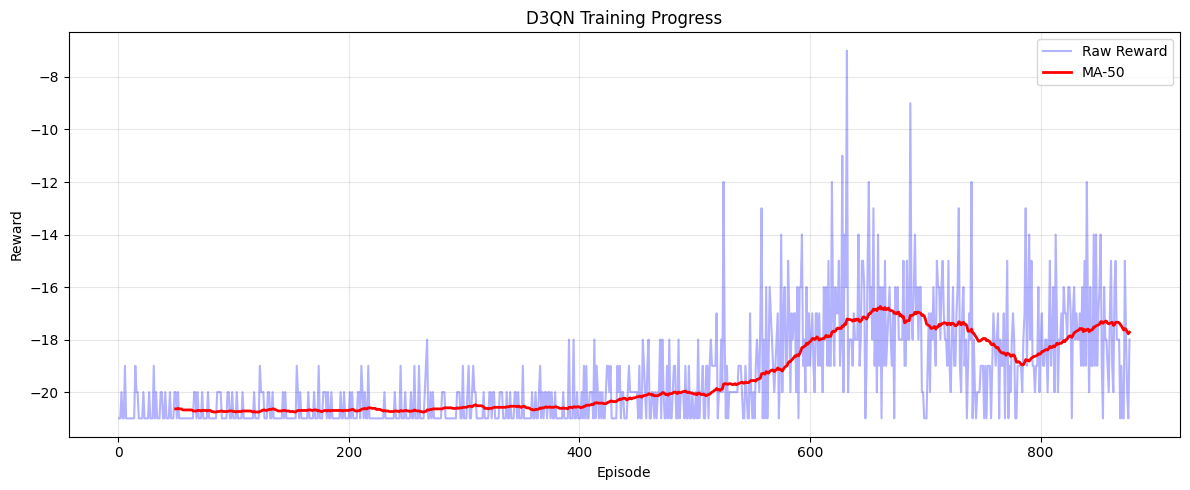

Total episodes: 877


In [22]:
import re as regex
import os

log_path = 'logs/training.log'
if not os.path.exists(log_path):
    print('Log chua co, hay train truoc!')
else:
    episodes_list, rewards_list = [], []
    with open(log_path, 'r') as f:
        for line in f:
            m = regex.search(r'ep=(\d+),\s*reward=([\-\d\.]+)', line)
            if m:
                episodes_list.append(int(m.group(1)))
                rewards_list.append(float(m.group(2)))
    plt.figure(figsize=(12, 5))
    plt.plot(episodes_list, rewards_list, alpha=0.3, color='blue', label='Raw Reward')
    window = 50
    if len(rewards_list) > window:
        smoothed = np.convolve(rewards_list, np.ones(window)/window, mode='valid')
        plt.plot(range(window, len(rewards_list)+1), smoothed, color='red', linewidth=2, label=f'MA-{window}')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('D3QN Training Progress')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curve.png', dpi=150)
    plt.show()
    print(f'Total episodes: {len(episodes_list)}')